In [2]:
import pandas as pd

df = pd.read_csv("ev_data_500.csv")
df.head()

,vehicle_id,model,model_year,battery_capacity,charging_time,distance,energy_used,temperature,location
0,1,Tata Nexon EV,2020,67,1.22,216,15,34,Delhi
1,2,Tesla Model 3,2020,54,2.11,100,25,33,Bangalore
2,3,Tata Nexon EV,2022,56,1.25,189,30,33,Delhi
3,4,Nissan Leaf,2023,49,1.95,202,17,38,Hyderabad
4,5,Tata Tigor EV,2024,56,1.71,250,20,35,Delhi


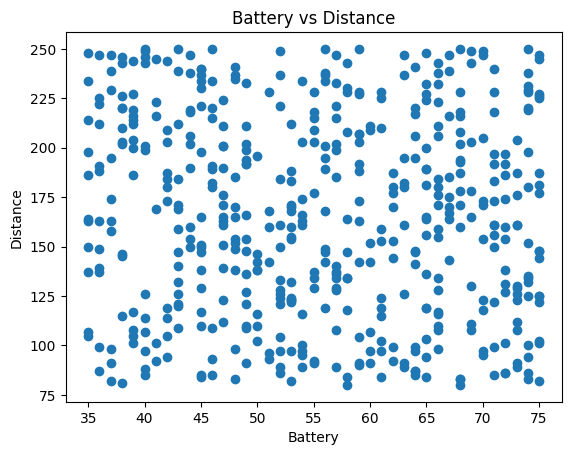

In [3]:
import matplotlib.pyplot as plt

plt.scatter(df['battery_capacity'], df['distance'])
plt.xlabel("Battery")
plt.ylabel("Distance")
plt.title("Battery vs Distance")
plt.show()

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   vehicle_id        500 non-null    int64  
 1   model             500 non-null    object 
 2   model_year        500 non-null    int64  
 3   battery_capacity  500 non-null    int64  
 4   charging_time     500 non-null    float64
 5   distance          500 non-null    int64  
 6   energy_used       500 non-null    int64  
 7   temperature       500 non-null    int64  
 8   location          500 non-null    object 
dtypes: float64(1), int64(6), object(2)
memory usage: 35.3+ KB


In [5]:
df.describe()

,vehicle_id,model_year,battery_capacity,charging_time,distance,energy_used,temperature
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,250.500000,2022.056000,55.654000,1.767580,165.216000,20.146000,33.254000
std,144.481833,1.448122,12.001097,0.424744,50.076068,5.984339,3.075125
min,1.000000,2020.000000,35.000000,1.000000,80.000000,10.000000,28.000000
25%,125.750000,2021.000000,45.000000,1.380000,123.000000,15.000000,31.000000
50%,250.500000,2022.000000,56.000000,1.800000,164.000000,20.000000,33.000000
75%,375.250000,2023.000000,66.000000,2.132500,208.000000,25.000000,36.000000
max,500.000000,2024.000000,75.000000,2.500000,250.000000,30.000000,38.000000


In [6]:
df.columns

Index(['vehicle_id', 'model', 'model_year', 'battery_capacity',
       'charging_time', 'distance', 'energy_used', 'temperature', 'location'],
      dtype='object')

In [7]:
df.isnull().sum()

vehicle_id          0
model               0
model_year          0
battery_capacity    0
charging_time       0
distance            0
energy_used         0
temperature         0
location            0
dtype: int64

In [9]:
df.drop_duplicates(inplace=True)

In [10]:
df['battery_capacity'].mean()

np.float64(55.654)

In [11]:
df['distance'].max()

np.int64(250)

In [14]:
df['energy_used'].min()

np.int64(10)

In [15]:
df.groupby('model')['distance'].mean()

model
Hyundai Kona     169.038961
MG ZS EV         168.065574
Nissan Leaf      163.323529
Tata Nexon EV    162.746667
Tata Tigor EV    173.776316
Tesla Model 3    164.944444
Tesla Model Y    154.154930
Name: distance, dtype: float64

In [16]:
df.groupby('location')['energy_used'].mean()

location
Bangalore    20.096386
Chennai      19.987500
Delhi        20.525000
Hyderabad    19.383721
Mumbai       21.035714
Pune         19.885057
Name: energy_used, dtype: float64

In [17]:
df.groupby('model')['charging_time'].mean()

model
Hyundai Kona     1.787532
MG ZS EV         1.755082
Nissan Leaf      1.806765
Tata Nexon EV    1.748000
Tata Tigor EV    1.768553
Tesla Model 3    1.706250
Tesla Model Y    1.800986
Name: charging_time, dtype: float64

In [18]:
df['efficiency'] = df['distance'] / df['energy_used']
df.head()

,vehicle_id,model,model_year,battery_capacity,charging_time,distance,energy_used,temperature,location,efficiency
0,1,Tata Nexon EV,2020,67,1.22,216,15,34,Delhi,14.400000
1,2,Tesla Model 3,2020,54,2.11,100,25,33,Bangalore,4.000000
2,3,Tata Nexon EV,2022,56,1.25,189,30,33,Delhi,6.300000
3,4,Nissan Leaf,2023,49,1.95,202,17,38,Hyderabad,11.882353
4,5,Tata Tigor EV,2024,56,1.71,250,20,35,Delhi,12.500000


In [19]:
df.sort_values(by='efficiency', ascending=False).head(5)

,vehicle_id,model,model_year,battery_capacity,charging_time,distance,energy_used,temperature,location,efficiency
404,405,Hyundai Kona,2021,68,2.25,250,10,34,Chennai,25.000000
314,315,Nissan Leaf,2024,56,1.83,238,10,34,Bangalore,23.800000
118,119,Tesla Model 3,2020,39,2.47,227,10,34,Mumbai,22.700000
20,21,Tesla Model 3,2023,70,1.75,249,11,33,Bangalore,22.636364
461,462,Tesla Model 3,2020,41,1.57,223,10,31,Mumbai,22.300000


In [20]:
df.sort_values(by='distance', ascending=False).head(5)

,vehicle_id,model,model_year,battery_capacity,charging_time,distance,energy_used,temperature,location,efficiency
4,5,Tata Tigor EV,2024,56,1.71,250,20,35,Delhi,12.500000
355,356,Tesla Model Y,2022,59,1.73,250,12,38,Hyderabad,20.833333
339,340,Nissan Leaf,2021,74,2.07,250,20,34,Mumbai,12.500000
233,234,Nissan Leaf,2024,40,1.23,250,23,33,Delhi,10.869565
468,469,Hyundai Kona,2024,46,1.75,250,12,36,Chennai,20.833333


In [21]:
df[df['temperature'] > 33]

,vehicle_id,model,model_year,battery_capacity,charging_time,distance,energy_used,temperature,location,efficiency
0,1,Tata Nexon EV,2020,67,1.22,216,15,34,Delhi,14.400000
3,4,Nissan Leaf,2023,49,1.95,202,17,38,Hyderabad,11.882353
4,5,Tata Tigor EV,2024,56,1.71,250,20,35,Delhi,12.500000
6,7,Tata Nexon EV,2024,53,2.00,170,18,35,Hyderabad,9.444444
8,9,Hyundai Kona,2021,65,2.33,119,21,34,Delhi,5.666667
...,...,...,...,...,...,...,...,...,...,...
491,492,MG ZS EV,2024,64,2.10,87,10,34,Mumbai,8.700000
494,495,Tesla Model Y,2024,64,1.58,220,10,35,Pune,22.000000
496,497,Tata Tigor EV,2024,46,1.87,180,24,35,Bangalore,7.500000
498,499,Tata Nexon EV,2020,66,1.97,232,24,35,Chennai,9.666667


In [22]:
df[df['distance'] > 150]

,vehicle_id,model,model_year,battery_capacity,charging_time,distance,energy_used,temperature,location,efficiency
0,1,Tata Nexon EV,2020,67,1.22,216,15,34,Delhi,14.400000
2,3,Tata Nexon EV,2022,56,1.25,189,30,33,Delhi,6.300000
3,4,Nissan Leaf,2023,49,1.95,202,17,38,Hyderabad,11.882353
4,5,Tata Tigor EV,2024,56,1.71,250,20,35,Delhi,12.500000
6,7,Tata Nexon EV,2024,53,2.00,170,18,35,Hyderabad,9.444444
...,...,...,...,...,...,...,...,...,...,...
494,495,Tesla Model Y,2024,64,1.58,220,10,35,Pune,22.000000
495,496,Hyundai Kona,2024,66,2.41,184,15,29,Chennai,12.266667
496,497,Tata Tigor EV,2024,46,1.87,180,24,35,Bangalore,7.500000
498,499,Tata Nexon EV,2020,66,1.97,232,24,35,Chennai,9.666667


In [24]:
import matplotlib.pyplot as plt

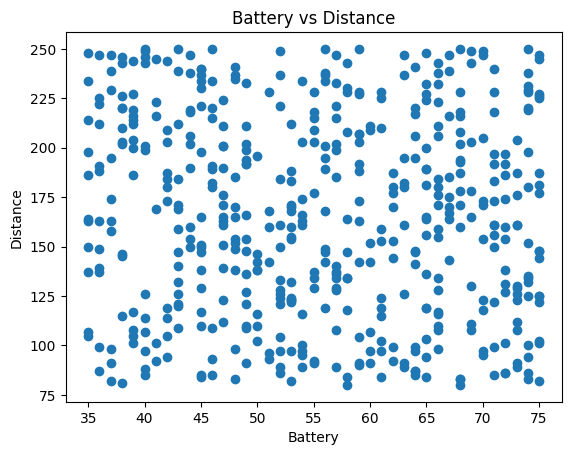

In [25]:
plt.scatter(df['battery_capacity'], df['distance'])
plt.xlabel("Battery")
plt.ylabel("Distance")
plt.title("Battery vs Distance")
plt.show()

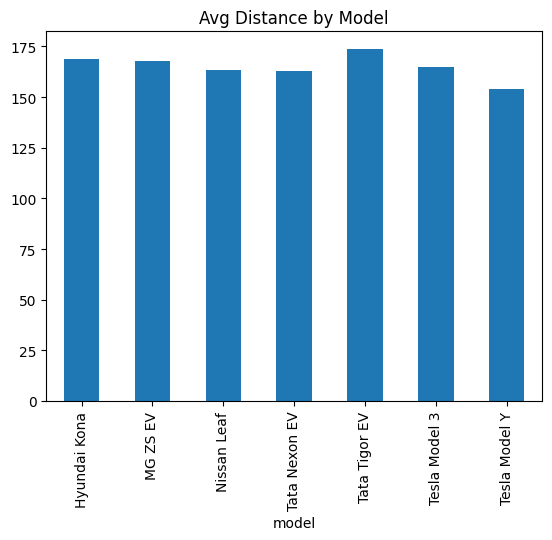

In [26]:
df.groupby('model')['distance'].mean().plot(kind='bar')
plt.title("Avg Distance by Model")
plt.show()

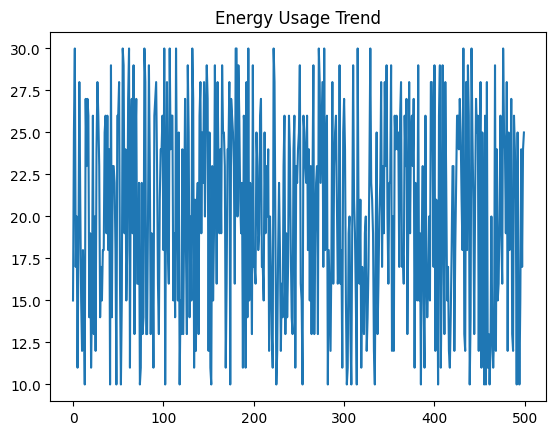

In [36]:
df['energy_used'].plot()
plt.title("Energy Usage Trend")
plt.show()

In [38]:
df.groupby('location')['efficiency'].mean().sort_values(ascending=False)

location
Hyderabad    9.701615
Bangalore    9.449424
Pune         9.375044
Chennai      9.250208
Delhi        8.519488
Mumbai       8.312670
Name: efficiency, dtype: float64

In [39]:
df.groupby('model')['efficiency'].mean().sort_values(ascending=False)

model
Tesla Model 3    9.675911
Hyundai Kona     9.465972
Tata Tigor EV    9.269823
Nissan Leaf      9.221648
Tesla Model Y    8.832880
MG ZS EV         8.667312
Tata Nexon EV    8.548604
Name: efficiency, dtype: float64

In [40]:
df['model'].value_counts()

model
Hyundai Kona     77
Tata Tigor EV    76
Tata Nexon EV    75
Tesla Model 3    72
Tesla Model Y    71
Nissan Leaf      68
MG ZS EV         61
Name: count, dtype: int64

In [41]:
df['efficiency'] = df['distance'] / df['energy_used']

In [42]:
df['efficiency'] = df['distance'] / df['energy_used']

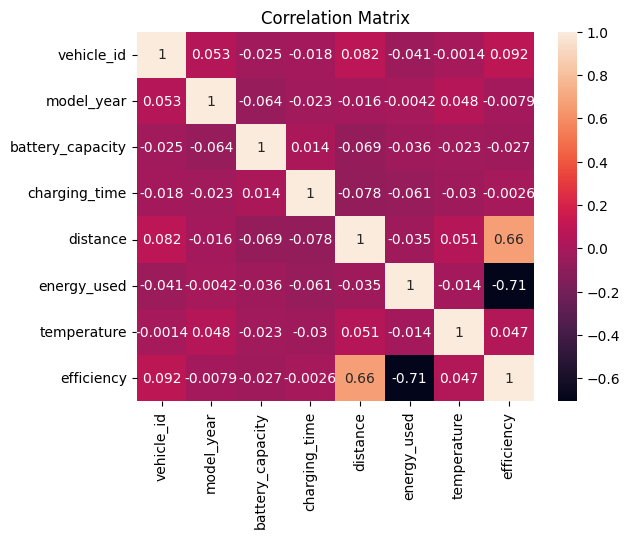

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

# select only numeric columns
numeric_df = df.select_dtypes(include=['number'])

sns.heatmap(numeric_df.corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

<Axes: >

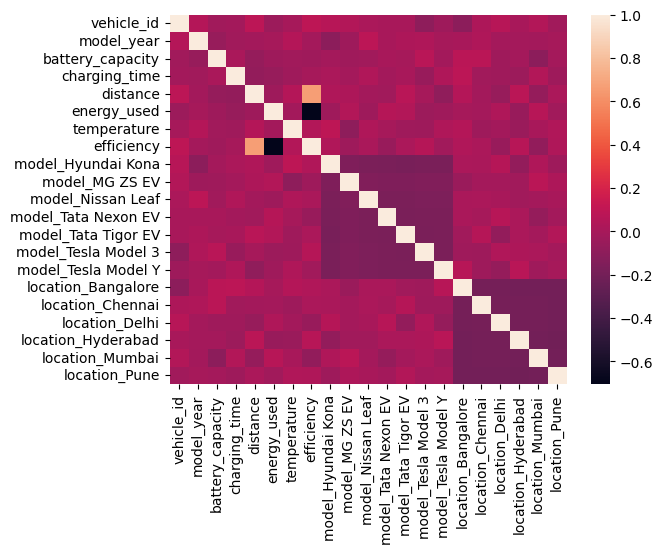

In [44]:
df_encoded = pd.get_dummies(df)
sns.heatmap(df_encoded.corr(), annot=False)

In [46]:
df['efficiency'] = df['distance'] / df['energy_used']

df.to_csv("ev_final.csv", index=False)

In [48]:
df.to_csv("ev_final.csv", index=False)